
# SVM Classification Project on Diabetes Dataset
# Dataset Source: GitHub Repository

# Step 1: Import Required Libraries


In [9]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Step 2: Load Dataset from GitHub


In [11]:
url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML/refs/heads/main/dataset/diabetes.csv"

df = pd.read_csv(url)

# Step 3: Display Dataset


In [12]:
print("\nFirst 5 Rows of Dataset:\n")

print(df.head())


First 5 Rows of Dataset:

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Step 4: Dataset Information


In [13]:

print("\nDataset Information:\n")

print(df.info())



Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


# Step 5: Dataset Shape

In [14]:
print("\nDataset Shape:")

print(df.shape)



Dataset Shape:
(768, 9)


 Step 6: Statistical Summary

In [ ]:
print("\nStatistical Summary:\n")

print(df.describe())

Step 7: Check Column Names

In [15]:
print("\nColumn Names:\n")

print(df.columns)


Column Names:

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


 Step 8: Separate Features and Target

In [16]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

 Step 9: Handle Missing Values

In [17]:
if df.isnull().sum().sum() > 0:

    X = X.fillna(X.median())

    print("\nMissing values filled using median")

 Step 10: Target Labels

In [18]:
target_names = ['No Diabetes', 'Diabetes']

print("\nTarget Distribution:\n")

print(y.value_counts())


Target Distribution:

Outcome
0    500
1    268
Name: count, dtype: int64


# Step 11: Split Data into Training and Testing Sets

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

 Step 12: Standardize Features

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Step 13: Hyperparameter Tuning using GridSearchCV

In [22]:
param_grid = [

    {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear']
    },

    {
        'C': [0.1, 1, 10, 100],
        'gamma': [1, 0.1, 0.01, 0.001],
        'kernel': ['rbf']
    },

    {
        'C': [0.1, 1, 10],
        'gamma': [0.1, 0.01],
        'degree': [2, 3],
        'kernel': ['poly']
    }
]


svm_model = SVC(random_state=42)


grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)


print("\n" + "="*70)

print("Starting Grid Search for Best Hyperparameters...")

print("="*70)


grid_search.fit(X_train_scaled, y_train)


print(f"\nBest Parameters Found: {grid_search.best_params_}")

print(f"Best Cross Validation Accuracy: {grid_search.best_score_:.4f}")


Starting Grid Search for Best Hyperparameters...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters Found: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.7821


 Step 14: Train Final SVM Model

In [23]:
best_svm = SVC(
    probability=True,
    random_state=42,
    **grid_search.best_params_
)

best_svm.fit(X_train_scaled, y_train)

SVC(C=100, gamma=0.001, probability=True, random_state=42)

# Step 15: Generate Predictions

In [24]:
y_pred = best_svm.predict(X_test_scaled)

y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]


Step 16: Calculate Evaluation Metrics

In [25]:
test_accuracy = accuracy_score(y_test, y_pred)

test_precision = precision_score(y_test, y_pred)

test_recall = recall_score(y_test, y_pred)

test_f1 = f1_score(y_test, y_pred)

test_auc = roc_auc_score(y_test, y_pred_proba)


print("\n" + "="*70)

print("EVALUATION METRICS")

print("="*70)

print(f"Accuracy  : {test_accuracy:.4f}")

print(f"Precision : {test_precision:.4f}")

print(f"Recall    : {test_recall:.4f}")

print(f"F1 Score  : {test_f1:.4f}")

print(f"AUC Score : {test_auc:.4f}")


EVALUATION METRICS
Accuracy  : 0.7446
Precision : 0.6897
Recall    : 0.4938
F1 Score  : 0.5755
AUC Score : 0.8342


# Step 17: Classification Report

In [26]:
print("\n" + "="*70)

print("Classification Report")

print("="*70)

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))


Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.76      0.88      0.82       150
    Diabetes       0.69      0.49      0.58        81

    accuracy                           0.74       231
   macro avg       0.73      0.69      0.70       231
weighted avg       0.74      0.74      0.73       231



# Step 18: Confusion Matrix Heatmap

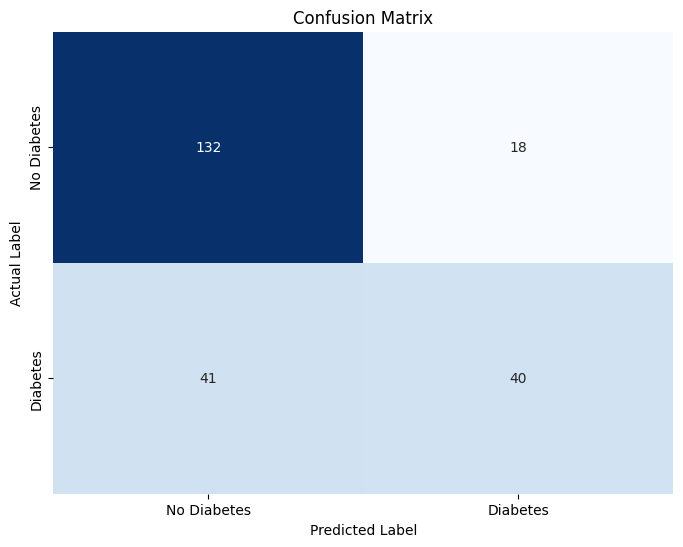

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Step 19: ROC Curve

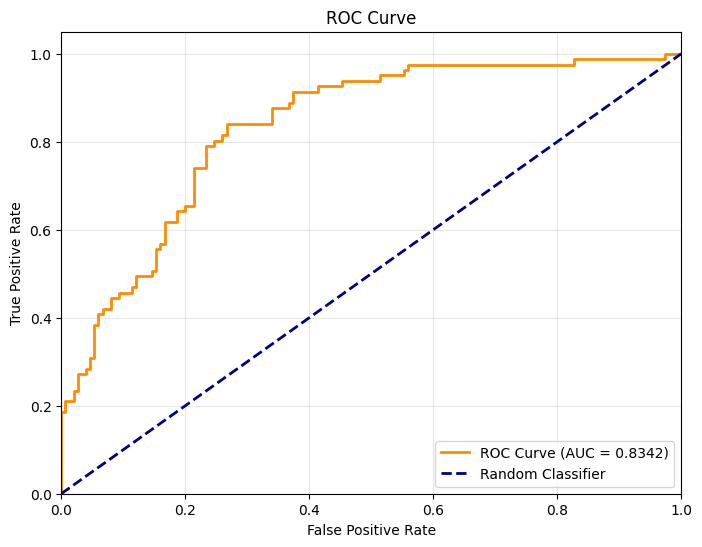

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Random Classifier'
)

plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.savefig(
    'roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Step 20: Sample Predictions Table

In [29]:
predictions_df = pd.DataFrame({

    'Actual_Class': y_test.values,

    'Predicted_Class': y_pred,

    'Actual_Name': [target_names[i] for i in y_test.values],

    'Predicted_Name': [target_names[i] for i in y_pred],

    'Probability_No_Diabetes':
        best_svm.predict_proba(X_test_scaled)[:, 0],

    'Probability_Diabetes':
        best_svm.predict_proba(X_test_scaled)[:, 1],

    'Correct_Prediction':
        y_test.values == y_pred
})


print("\n" + "="*70)

print("Sample Predictions")

print("="*70)

print(predictions_df.head(15).to_string(index=False))



Sample Predictions
 Actual_Class  Predicted_Class Actual_Name Predicted_Name  Probability_No_Diabetes  Probability_Diabetes  Correct_Prediction
            1                0    Diabetes    No Diabetes                 0.762390              0.237610               False
            1                0    Diabetes    No Diabetes                 0.698322              0.301678               False
            1                1    Diabetes       Diabetes                 0.318176              0.681824                True
            1                1    Diabetes       Diabetes                 0.408609              0.591391                True
            1                0    Diabetes    No Diabetes                 0.614914              0.385086               False
            0                0 No Diabetes    No Diabetes                 0.889243              0.110757                True
            0                1 No Diabetes       Diabetes                 0.320669              0.679331 

# Step 21: Visualization of Sample Predictions

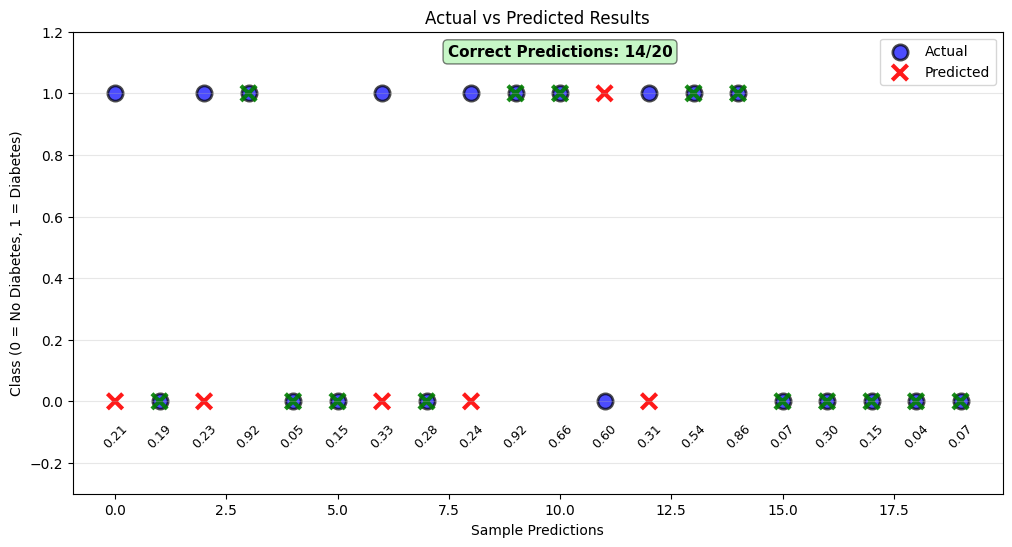

In [30]:
sample_size = min(20, len(y_test))

sample_indices = np.random.choice(
    len(y_test),
    sample_size,
    replace=False
)

sample_actual = y_test.iloc[sample_indices].values

sample_pred = y_pred[sample_indices]

sample_proba = y_pred_proba[sample_indices]


plt.figure(figsize=(12, 6))

x_pos = np.arange(sample_size)


colors_pred = [

    'green' if a == p else 'red'

    for a, p in zip(sample_actual, sample_pred)
]


plt.scatter(
    x_pos,
    sample_actual,
    c='blue',
    marker='o',
    s=120,
    label='Actual',
    alpha=0.7,
    edgecolors='black',
    linewidth=2
)


plt.scatter(
    x_pos,
    sample_pred,
    c=colors_pred,
    marker='x',
    s=120,
    label='Predicted',
    alpha=0.9,
    linewidth=3
)


for i, (x, prob) in enumerate(zip(x_pos, sample_proba)):

    plt.text(
        x,
        -0.15,
        f'{prob:.2f}',
        ha='center',
        fontsize=9,
        rotation=45
    )


plt.ylim([-0.3, 1.2])

plt.ylabel('Class (0 = No Diabetes, 1 = Diabetes)')

plt.xlabel('Sample Predictions')

plt.title('Actual vs Predicted Results')

plt.grid(alpha=0.3, axis='y')

plt.legend()


correct_count = sum([
    1 for a, p in zip(sample_actual, sample_pred)
    if a == p
])


plt.text(
    sample_size/2,
    1.12,
    f'Correct Predictions: {correct_count}/{sample_size}',
    ha='center',
    fontsize=11,
    fontweight='bold',
    bbox=dict(
        boxstyle='round',
        facecolor='lightgreen',
        alpha=0.5
    )
)

plt.savefig(
    'sample_predictions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Step 22: 2D Decision Boundary Visualization

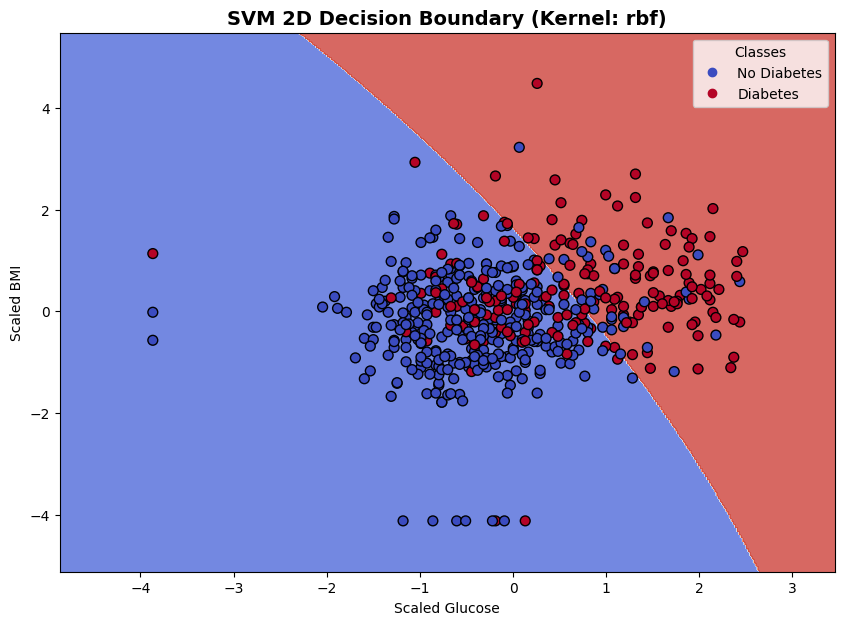

In [31]:
features_2D = ['Glucose', 'BMI']

X_2D = X[features_2D]


X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)


svm_params = {

    'kernel': best_svm.kernel,

    'C': best_svm.C,

    'random_state': 42
}


if hasattr(best_svm, 'gamma') and best_svm.kernel in ['rbf', 'poly', 'sigmoid']:

    svm_params['gamma'] = best_svm.gamma


if hasattr(best_svm, 'degree') and best_svm.kernel == 'poly':

    svm_params['degree'] = best_svm.degree


svm_2D = SVC(**svm_params)

svm_2D.fit(X_train_2D_scaled, y_train_2D)


h = 0.02


x_min, x_max = (
    X_train_2D_scaled[:, 0].min() - 1,
    X_train_2D_scaled[:, 0].max() + 1
)

y_min, y_max = (
    X_train_2D_scaled[:, 1].min() - 1,
    X_train_2D_scaled[:, 1].max() + 1
)


xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)


Z = svm_2D.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.8,
    cmap=plt.cm.coolwarm
)


scatter = plt.scatter(
    X_train_2D_scaled[:, 0],
    X_train_2D_scaled[:, 1],
    c=y_train_2D,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    marker='o',
    s=50,
    linewidth=1
)


handles, _ = scatter.legend_elements()


plt.legend(
    handles,
    target_names,
    title="Classes",
    loc='best'
)


plt.title(
    f'SVM 2D Decision Boundary (Kernel: {best_svm.kernel})',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(f'Scaled {features_2D[0]}')

plt.ylabel(f'Scaled {features_2D[1]}')


plt.savefig(
    '2d_decision_boundary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()